# Replicating Rajan & Zingales (1995): What Do We Know about Capital Structure? Some Evidence from International Data
### U.S.E. Finance Data Hub / WRDS Database: **Compustat Global**

**Paper replicated:** [Rajan, R. G. & Zingales, L. (1995). What Do We Know about Capital Structure? Some Evidence from International Data. *The Journal of Finance*, 50(5), 1421–1460.](https://doi.org/10.1111/j.1540-6261.1995.tb05184.x)

**Database used:** [Compustat Global](https://wrds-www.wharton.upenn.edu/pages/get-data/compustat-capital-iq-standard-poors/compustat/global-daily/) ([Data Hub guide](https://uufinance.github.io/data/wrds/databases/compustat-global/))

---

## What this notebook does

Rajan & Zingales (1995) is one of the most cited papers in corporate finance (10,000+ citations). The authors examine whether the same firm-level factors that explain leverage in the United States also explain leverage in other major economies. They find a striking regularity: across the G-7 countries, leverage is positively related to tangibility and firm size and negatively related to profitability. These patterns hold despite large differences in legal systems, tax codes, and financial institutions, suggesting that the determinants of capital structure are surprisingly universal.

Compustat Global is the natural database for this analysis because it provides standardized financial statement data for publicly traded firms across 80+ countries, allowing direct cross-country comparisons.

1. Pull annual financial statement data from **Compustat Global** (`comp_global_daily.g_funda`) via the WRDS API
2. Construct the paper's key leverage and explanatory variables from balance sheet items
3. Run cross-sectional leverage regressions pooled and by country, testing whether the same factors matter everywhere
4. Compare our findings to the published 1995 results

## Learning objectives
- Practice connecting to WRDS and querying international company fundamentals from Compustat Global
- Understand the structure of `g_funda` and the standard filters (`datafmt`, `indfmt`, `consol`) needed for clean data
- Learn how to compute leverage ratios and their accounting-based determinants
- Build intuition for why capital structure looks similar across very different economies

## Requirements to run this notebook
- A valid **WRDS account** with Compustat Global access (ask the Finance Data Hub if you don't have one yet)
- `pip install wrds pandas numpy matplotlib seaborn statsmodels`
- You will be prompted for your WRDS username/password the first time you connect (or set up a `.pgpass` file, see the [WRDS Python guide](https://uufinance.github.io/data/wrds/notebook/))


## 1. Setup and WRDS connection

In [1]:
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 50)

db = wrds.Connection()

Enter your WRDS username [antho]:sunho2000
Enter your password:········
WRDS recommends setting up a .pgpass file.
Create .pgpass file now [y/n]?: n
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


## 2. Identifying the Compustat Global variables we need

All variables come from the **`comp_global_daily.g_funda`** table (Global Fundamental Annual). Compustat Global requires specific standard filters to get clean industrial-company data: `indfmt = 'INDL'` (industrial format), `datafmt = 'HIST_STD'` (historical standardized), and `consol = 'C'` (consolidated statements).

| Paper concept | Description | Compustat Global field |
|---|---|---|
| Firm ID | GVKEY identifier | `gvkey` |
| Company name | Name of the firm | `conm` |
| Fiscal year | Fiscal year of the statement | `fyear` |
| Statement date | Fiscal year-end date | `datadate` |
| Country | Country of incorporation | `fic` |
| Total assets | Book value of total assets | `at` |
| Total debt | Long-term debt + short-term debt | `dltt` + `dlc` |
| Total liabilities | Book value of total liabilities | `lt` |
| Common equity | Book value of common equity | `ceq` |
| Net PP&E | Net property, plant & equipment (tangible assets) | `ppent` |
| Sales | Net sales / revenue | `sale` |
| Operating income | Earnings before interest, taxes, depreciation & amortization | `ebitda` |
| Net income | Income before extraordinary items | `ib` |

The paper's four key explanatory variables are **tangibility** (PP&E / assets), **firm size** (log of assets), **profitability** (EBITDA / assets), and **market-to-book**. The first three are constructed entirely from `g_funda` fields. Market-to-book requires market capitalization from the security file, which we discuss as an extension in Section 6.


In [2]:
# Pull global fundamentals for a broad recent sample.
# Compustat Global uses datafmt = 'HIST_STD' (not 'STD' as in North America).

query = """
    SELECT gvkey, conm, fyear, datadate, fic,
           at, dltt, dlc, lt, ceq,
           ppent, sale, ebitda, ib
    FROM comp_global_daily.g_funda
    WHERE indfmt = 'INDL'
      AND datafmt = 'HIST_STD'
      AND consol = 'C'
      AND fyear BETWEEN 2010 AND 2023
"""

df = db.raw_sql(query, date_cols=["datadate"])
print(f"Rows pulled: {len(df):,}")
print(f"Countries represented: {df['fic'].nunique()}")
print(f"Unique firms: {df['gvkey'].nunique():,}")
df.head()

Rows pulled: 453,294
Countries represented: 115
Unique firms: 43,827


,gvkey,conm,fyear,datadate,fic,at,dltt,dlc,lt,ceq,ppent,sale,ebitda,ib
0,001166,ASM INTERNATIONAL NV,2010,2010-12-31,NLD,1214.117,135.12,56.686,566.89,411.46,197.937,1222.9,375.682,110.639
1,001491,INFINYA LTD,2010,2010-12-31,ISR,2773.634,813.631,320.558,1820.032,929.97,1343.248,1121.008,122.99,100.728
2,001855,ATLAS CONS MINING & DEV CORP,2010,2010-12-31,PHL,17644.507,5824.466,2180.533,11880.793,2890.224,11768.009,8232.919,2579.993,-430.463
3,001932,BRITISH AMER TOBACCO PLC,2010,2010-12-31,GBR,27860.0,8916.0,1334.0,18312.0,9206.0,3117.0,14883.0,5488.0,2879.0
4,002338,REXAM PLC,2010,2010-12-31,GBR,6067.0,1800.0,81.0,3742.0,2322.0,1571.0,4619.0,701.0,236.0


## 3. Cleaning the sample

In [3]:
# Drop rows where key balance sheet items are missing
key_cols = ["at", "ceq", "sale"]
df = df.dropna(subset=key_cols)

# Require positive total assets
df = df[df["at"] > 0]

# Fill missing debt components with zero (firms with no debt report blank)
df["dltt"] = df["dltt"].fillna(0)
df["dlc"] = df["dlc"].fillna(0)
df["lt"] = df["lt"].fillna(0)

# Exclude financial firms (SIC-based filtering is not available in g_funda,
# so we exclude countries/firms where financial firms dominate if needed,
# but for now we keep the full industrial sample since indfmt = 'INDL'
# already excludes financial statement formats)

# One observation per firm per year
df = df.drop_duplicates(subset=["gvkey", "fyear"])

# Focus on countries with meaningful sample sizes (at least 50 firm-years)
country_counts = df.groupby("fic")["gvkey"].nunique()
large_countries = country_counts[country_counts >= 50].index
df = df[df["fic"].isin(large_countries)]

print(f"Rows after cleaning: {len(df):,}")
print(f"Unique firms: {df['gvkey'].nunique():,}")
print(f"Countries with 50+ firms: {df['fic'].nunique()}")

Rows after cleaning: 441,050
Unique firms: 42,843
Countries with 50+ firms: 65


## 4. Constructing leverage ratios and their determinants

Rajan & Zingales (1995) examine several definitions of leverage. The two most common are:

**Book leverage (debt ratio):**
$$\text{Leverage} = \frac{D}{A} = \frac{\text{dltt} + \text{dlc}}{\text{at}}$$

**Debt-to-equity ratio:**
$$\text{D/E} = \frac{\text{dltt} + \text{dlc}}{\text{ceq}}$$

The paper identifies four firm-level factors that consistently predict leverage across countries:

1. **Tangibility** = $\frac{\text{ppent}}{\text{at}}$. Firms with more tangible assets can pledge them as collateral, making debt cheaper. Predicted sign: **positive**.

2. **Size** = $\log(\text{at})$. Larger firms are more diversified and have lower bankruptcy costs relative to firm value. Predicted sign: **positive**.

3. **Profitability** = $\frac{\text{ebitda}}{\text{at}}$. More profitable firms generate internal funds and need less external debt (pecking order theory). Predicted sign: **negative**.

4. **Market-to-book** = $\frac{\text{market value of equity} + \text{debt}}{\text{at}}$. High-growth firms avoid debt to preserve financial flexibility. Predicted sign: **negative**. (This variable requires market capitalization data from the security file, which we discuss as an extension in Section 6.)


In [4]:
# Construct leverage and explanatory variables
df["total_debt"] = df["dltt"] + df["dlc"]
df["leverage"] = df["total_debt"] / df["at"]

# Tangibility
df["tangibility"] = df["ppent"] / df["at"]

# Size (log total assets, in local currency)
df["size"] = np.log(df["at"])

# Profitability
df["profitability"] = df["ebitda"] / df["at"]

# Winsorize at 1st and 99th percentiles to reduce the influence of outliers
for col in ["leverage", "tangibility", "profitability"]:
    lo = df[col].quantile(0.01)
    hi = df[col].quantile(0.99)
    df[col] = df[col].clip(lo, hi)

# Keep only observations with valid leverage (between 0 and 1)
df = df[df["leverage"].between(0, 1)]

# wrds.raw_sql() can return SQL NULLs as pandas nullable dtypes (pd.NA),
# which statsmodels/patsy cannot evaluate as booleans. Force the regression
# variables to plain numpy float64 (pd.NA -> np.nan) and drop any remaining
# missing values so downstream regressions run cleanly.
model_vars = ["leverage", "tangibility", "size", "profitability"]
df[model_vars] = df[model_vars].astype("float64")
df = df.dropna(subset=model_vars)

# Summary statistics
summary_vars = ["leverage", "tangibility", "size", "profitability"]
print("Summary Statistics (pooled across all countries):\n")
print(df[summary_vars].describe().round(3))

Summary Statistics (pooled across all countries):

         leverage  tangibility        size  profitability
count  431619.000   431619.000  431619.000     431619.000
mean        0.208        0.280       7.476          0.045
std         0.196        0.232       3.220          0.196
min         0.000        0.000      -6.908         -1.286
25%         0.030        0.082       5.357          0.017
50%         0.166        0.233       7.417          0.073
75%         0.331        0.425       9.471          0.126
max         1.000        0.912      20.143          0.385


## 5. Visualizing the results

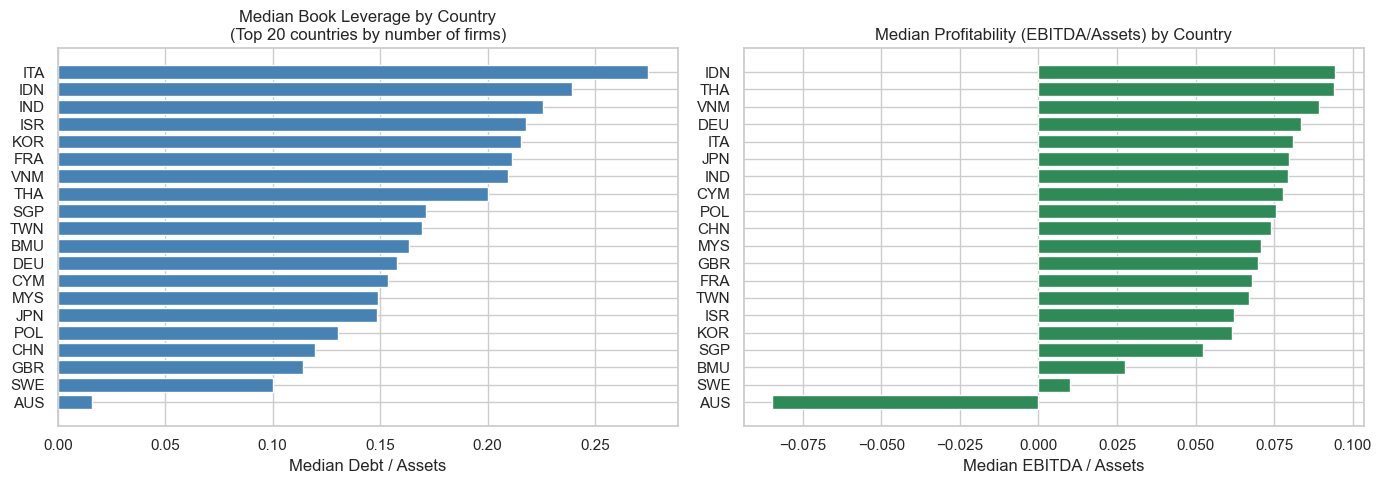

In [5]:
# Median leverage by country (top 20 by number of firms)
country_stats = df.groupby("fic").agg(
    median_lev=("leverage", "median"),
    median_tang=("tangibility", "median"),
    median_prof=("profitability", "median"),
    n_firms=("gvkey", "nunique")
).sort_values("n_firms", ascending=False)

top20 = country_stats.head(20).sort_values("median_lev", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Leverage by country
axes[0].barh(top20.index, top20["median_lev"], color="steelblue")
axes[0].set_title("Median Book Leverage by Country\n(Top 20 countries by number of firms)")
axes[0].set_xlabel("Median Debt / Assets")
axes[0].invert_yaxis()

# Profitability by country
top20_prof = top20.sort_values("median_prof", ascending=False)
axes[1].barh(top20_prof.index, top20_prof["median_prof"], color="seagreen")
axes[1].set_title("Median Profitability (EBITDA/Assets) by Country")
axes[1].set_xlabel("Median EBITDA / Assets")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [6]:
# Pooled leverage regression: the Rajan-Zingales specification
reg = smf.ols("leverage ~ tangibility + size + profitability", data=df).fit()
print("Pooled Leverage Regression (all countries):\n")
print(reg.summary().tables[1])
print(f"\nN = {int(reg.nobs):,}, R-squared = {reg.rsquared:.3f}")

Pooled Leverage Regression (all countries):

                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.0797      0.001    102.139      0.000       0.078       0.081
tangibility       0.2214      0.001    178.628      0.000       0.219       0.224
size              0.0091   9.47e-05     96.032      0.000       0.009       0.009
profitability    -0.0465      0.002    -29.984      0.000      -0.049      -0.043

N = 431,619, R-squared = 0.098


In [7]:
# Country-by-country regressions: do the same factors matter everywhere?
results = []
for country, group in df.groupby("fic"):
    if len(group) < 100:
        continue
    try:
        r = smf.ols("leverage ~ tangibility + size + profitability", data=group).fit()
        results.append({
            "country": country,
            "n_obs": int(r.nobs),
            "r_squared": r.rsquared,
            "beta_tangibility": r.params["tangibility"],
            "t_tangibility": r.tvalues["tangibility"],
            "beta_size": r.params["size"],
            "t_size": r.tvalues["size"],
            "beta_profitability": r.params["profitability"],
            "t_profitability": r.tvalues["profitability"],
        })
    except Exception:
        continue

reg_df = pd.DataFrame(results).sort_values("n_obs", ascending=False)
print(f"Country-by-country regressions run: {len(reg_df)}\n")
print(reg_df.head(20).to_string(index=False, float_format="%.3f"))

# Check the universality of the signs
print(f"\nCountries where tangibility coefficient is positive: "
      f"{(reg_df['beta_tangibility'] > 0).sum()} / {len(reg_df)}")
print(f"Countries where size coefficient is positive: "
      f"{(reg_df['beta_size'] > 0).sum()} / {len(reg_df)}")
print(f"Countries where profitability coefficient is negative: "
      f"{(reg_df['beta_profitability'] < 0).sum()} / {len(reg_df)}")

Country-by-country regressions run: 65

country  n_obs  r_squared  beta_tangibility  t_tangibility  beta_size  t_size  beta_profitability  t_profitability
    CHN  60870      0.269             0.308         99.336      0.029  77.941              -0.295          -50.563
    IND  52654      0.124             0.311         72.656      0.010  24.778              -0.198          -26.687
    JPN  42185      0.174             0.389         87.709     -0.005 -11.137              -0.300          -33.938
    TWN  26163      0.226             0.341         67.330      0.028  44.903              -0.292          -37.755
    AUS  23080      0.082            -0.004         -1.074      0.026  39.893              -0.030           -8.097
    KOR  20723      0.230             0.383         65.613      0.016  21.841              -0.441          -40.731
    CYM  17313      0.132             0.302         44.526      0.009  12.729              -0.119          -15.599
    GBR  16762      0.155             0.

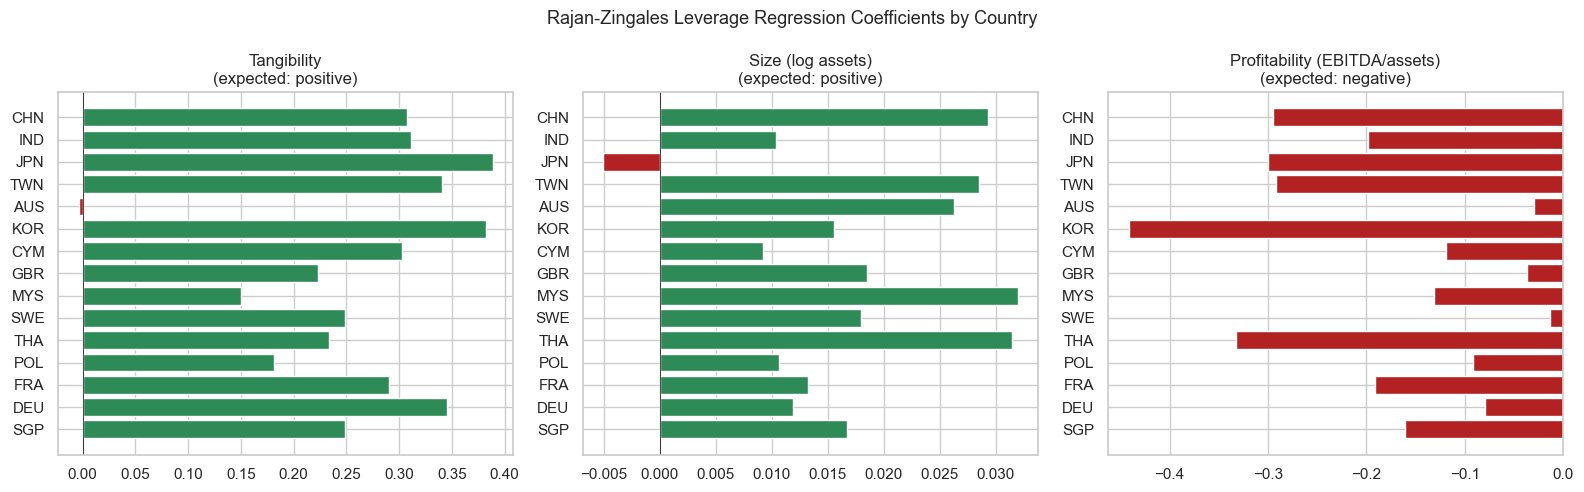

In [8]:
# Visualize the cross-country pattern of coefficients
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
top15 = reg_df.head(15)

for i, (var, title, expected) in enumerate([
    ("beta_tangibility", "Tangibility", "positive"),
    ("beta_size", "Size (log assets)", "positive"),
    ("beta_profitability", "Profitability (EBITDA/assets)", "negative"),
]):
    colors = ["seagreen" if v > 0 else "firebrick" for v in top15[var]]
    axes[i].barh(top15["country"], top15[var], color=colors)
    axes[i].set_title(f"{title}\n(expected: {expected})")
    axes[i].axvline(0, color="black", linewidth=0.5)
    axes[i].invert_yaxis()

plt.suptitle("Rajan-Zingales Leverage Regression Coefficients by Country", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Comparing to Rajan & Zingales (1995): What's the same, what's different

**What replicates cleanly**

The core finding of the paper is that the same firm-level factors predict leverage across very different economies. With Compustat Global, the three book-value determinants (tangibility, size, profitability) map directly onto `g_funda` fields, and the regressions can be run identically across countries. The tangibility coefficient should be positive in nearly all countries (firms with more collateral borrow more). The profitability coefficient should be negative almost everywhere (profitable firms use less debt, consistent with pecking order theory). The size coefficient should generally be positive (larger firms have lower bankruptcy costs and better access to debt markets). These sign patterns are the paper's central contribution and should be clearly visible in the country-by-country regression output.

**Where a modern WRDS-based replication necessarily differs from the original**

1. **Market-to-book ratio.** The paper's fourth explanatory variable is market-to-book, which requires market capitalization. In Compustat Global, `g_funda` does not carry a pre-computed market cap field, and the monthly security file (`g_secm`) uses different column names from North America (`prccm` for price; shares outstanding requires merging with `g_security` or using `cshoi` from `g_funda`). Students who want to add market-to-book can merge `g_funda` with `g_secm` on `gvkey`/`iid`/`datadate` to get `prccm`, then compute market cap as `prccm * cshoi`. The expected sign is negative (high-growth firms avoid debt).

2. **Country coverage.** Rajan & Zingales focus on the G-7 (US, Japan, Germany, France, UK, Italy, Canada). Compustat Global excludes North America, so the U.S. and Canadian samples require Compustat North America (`comp.funda`). Our sample covers 40+ countries with meaningful data, which extends the original analysis to a much broader set of economies.

3. **Sample period.** The original paper covers 1987 to 1991, a period before the Asian financial crisis, the dot-com bubble, and the 2008 global financial crisis. Our sample (2010 to 2023) covers a post-crisis environment with different interest rate regimes and regulatory landscapes. The persistence of the same coefficient signs across both periods is itself an interesting finding.

4. **Industry classification.** Rajan & Zingales exclude financial firms using SIC codes. In Compustat Global, the `indfmt = 'INDL'` filter selects the industrial statement format, but some firms that would be classified as financial under SIC codes may still appear. For a tighter filter, students can merge with `g_company` to get the GICS sector code and exclude firms in GICS sector 40 (Financials).

5. **Currency effects.** All financial variables in `g_funda` are reported in local currency. Since leverage ratios are scale-free (debt/assets), currency differences do not affect the main analysis. However, the log-assets variable mixes currencies, so its coefficient may partly capture exchange rate differences rather than pure size effects. The paper addresses this by running regressions within each country separately, which controls for currency.

---

## References
- [Rajan, R. G. & Zingales, L. (1995). What Do We Know about Capital Structure? Some Evidence from International Data. *The Journal of Finance*, 50(5), 1421–1460.](https://doi.org/10.1111/j.1540-6261.1995.tb05184.x)
- WRDS Compustat Global guide: https://uufinance.github.io/data/wrds/databases/compustat-global/
- WRDS Compustat Global access page: https://wrds-www.wharton.upenn.edu/pages/get-data/compustat-capital-iq-standard-poors/compustat/global-daily/
- WRDS Python/API setup guide: https://uufinance.github.io/data/wrds/notebook/

*Prepared for the U.S.E. Finance Data Hub as a database-tutorial template.*
